In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier


data = pd.read_csv("dataset3.csv")
print(data.columns.tolist())

['User', 'Date', 'Content', 'Hashtags', 'Mentions', 'Views', 'Likes', 'Retweets', 'Replies']


In [12]:
print(data.shape)
print(data.columns)
print(data.info())
print(data.describe())

(334, 9)
Index(['User', 'Date', 'Content', 'Hashtags', 'Mentions', 'Views', 'Likes',
       'Retweets', 'Replies'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   User      333 non-null    object
 1   Date      334 non-null    object
 2   Content   334 non-null    object
 3   Hashtags  56 non-null     object
 4   Mentions  334 non-null    object
 5   Views     334 non-null    int64 
 6   Likes     334 non-null    int64 
 7   Retweets  334 non-null    int64 
 8   Replies   334 non-null    int64 
dtypes: int64(4), object(5)
memory usage: 23.6+ KB
None
              Views         Likes     Retweets       Replies
count  3.340000e+02    334.000000   334.000000  3.340000e+02
mean   1.047574e+05   2468.248503   492.988024  1.040571e+05
std    7.184425e+05   5623.252453  1008.964867  1.897393e+06
min    0.000000e+00      0.000000     0.

# Feature Engineering

In [13]:
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
data['publish_hour'] = data['Date'].dt.hour.fillna(12).astype(int)
data['publish_weekday'] = data['Date'].dt.dayofweek.fillna(0).astype(int)
data['publish_month'] = data['Date'].dt.month.fillna(1).astype(int)


data['hashtag_count'] = data['Hashtags'].astype(str).str.count('#')
data['hashtag_length'] = data['Hashtags'].astype(str).str.len()


data['like_view_ratio'] = (data['Likes'] / data['Views'].replace(0, np.nan)).fillna(0)
data['retweet_view_ratio'] = (data['Retweets'] / data['Views'].replace(0, np.nan)).fillna(0)
data['reply_view_ratio'] = (data['Replies'] / data['Views'].replace(0, np.nan)).fillna(0)


data['content_length'] = data['Content'].astype(str).str.len()
data['word_count'] = data['Content'].astype(str).str.split().str.len()
data['mention_count'] = data['Mentions'].astype(str).str.count('@')


data['engagement_score'] = (
    data['Likes'] * 0.4 + 
    data['Retweets'] * 0.3 + 
    data['Replies'] * 0.3
)

In [14]:
threshold = data['Views'].quantile(0.7)
data['high_views'] = (data['Views'] >= threshold).astype(int)

# EDA

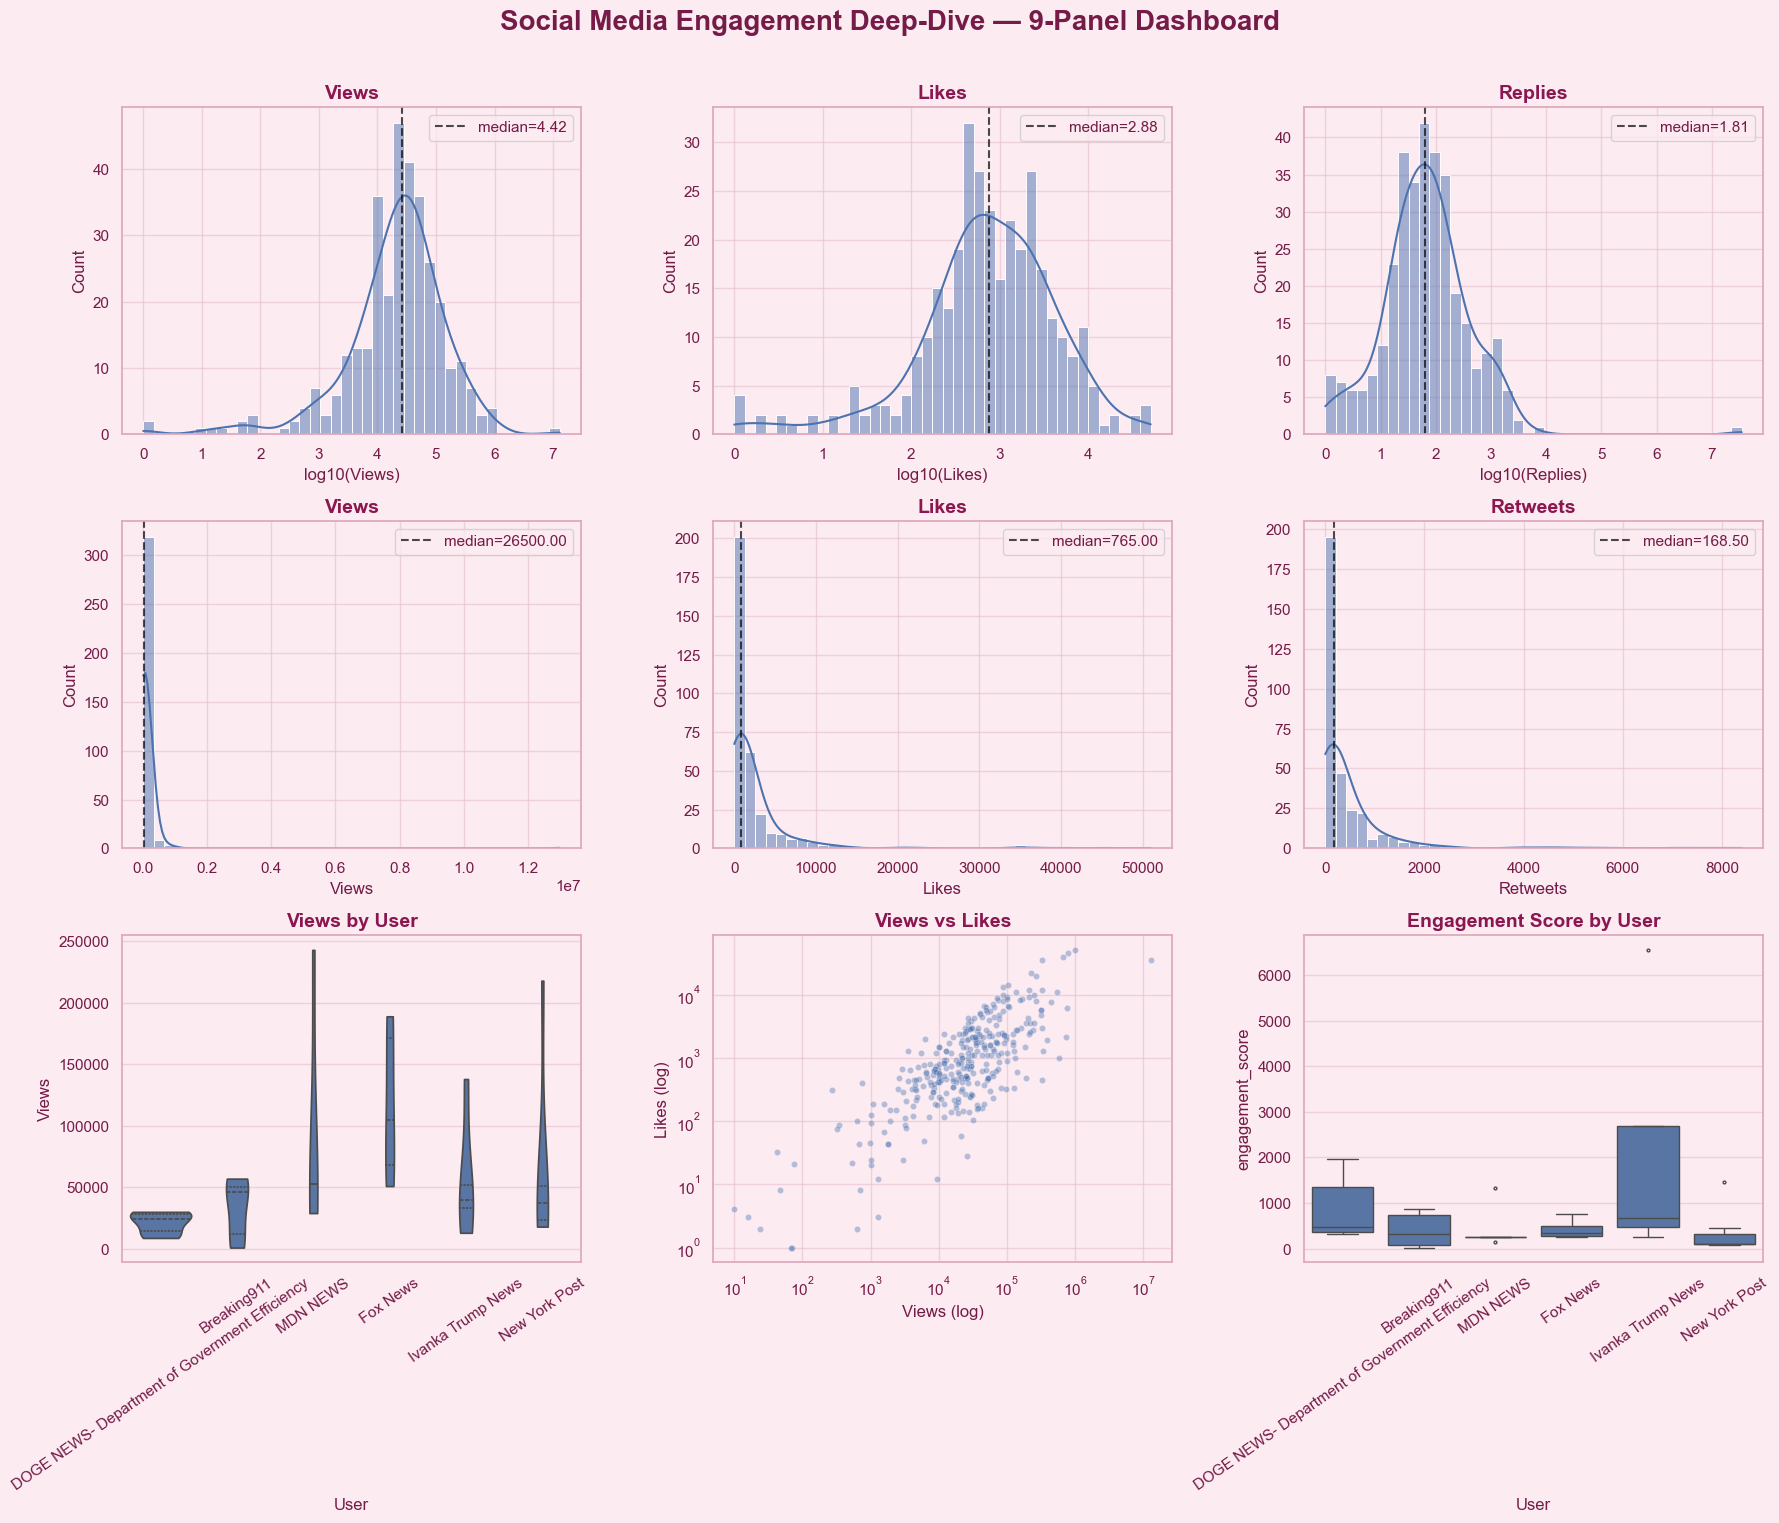

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle("Social Media Engagement Deep-Dive — 9-Panel Dashboard", fontsize=20, fontweight='bold', y=0.98)

for i, col in enumerate(["Views", "Likes", "Replies"]):
    if col in data.columns:
        log_data = np.log10(data[col].clip(lower=1))
        sns.histplot(log_data, bins=40, kde=True, ax=axes[0, i])
        median_val = log_data.median()
        axes[0, i].axvline(median_val, color='black', linestyle='--', alpha=0.7, 
                           label=f"median={median_val:.2f}")
        axes[0, i].set_title(col, fontsize=14, fontweight='bold')
        axes[0, i].set_xlabel(f"log10({col})")
        axes[0, i].legend()

for i, col in enumerate(["Views", "Likes", "Retweets"]):
    if col in data.columns:
        sns.histplot(data[col], bins=40, kde=True, ax=axes[1, i])
        median_val = data[col].median()
        axes[1, i].axvline(median_val, color='black', linestyle='--', alpha=0.7, 
                           label=f"median={median_val:.2f}")
        axes[1, i].set_title(col, fontsize=14, fontweight='bold')
        axes[1, i].set_xlabel(col)
        axes[1, i].legend()

top_users = data["User"].value_counts().head(6).index
sns.violinplot(data=data[data["User"].isin(top_users)], x="User", y="Views", 
               ax=axes[2, 0], inner="quartile", cut=0)
axes[2, 0].set_title("Views by User", fontsize=14, fontweight='bold')
axes[2, 0].tick_params(axis='x', rotation=35)

sample_df = data.sample(min(len(data), 3000), random_state=42)
sns.scatterplot(data=sample_df, x="Views", y="Likes", ax=axes[2, 1], alpha=0.4, s=20)
axes[2, 1].set_xscale("log")
axes[2, 1].set_yscale("log")
axes[2, 1].set_title("Views vs Likes", fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel("Views (log)")
axes[2, 1].set_ylabel("Likes (log)")

if 'engagement_score' in data.columns:
    top_users_ret = data["User"].value_counts().head(6).index
    sns.boxplot(data=data[data["User"].isin(top_users_ret)], x="User", y="engagement_score", ax=axes[2, 2], fliersize=2)
    axes[2, 2].set_title("Engagement Score by User", fontsize=14, fontweight='bold')
else:
    top_users_ret = data["User"].value_counts().head(6).index
    sns.boxplot(data=data[data["User"].isin(top_users_ret)], x="User", y="Retweets", ax=axes[2, 2], fliersize=2)
    axes[2, 2].set_title("Retweets by User", fontsize=14, fontweight='bold')

axes[2, 2].tick_params(axis='x', rotation=35)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

/var/folders/xz/jl0x7g45257404n2n3_cp3xh0000gn/T/ipykernel_2429/3587280277.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


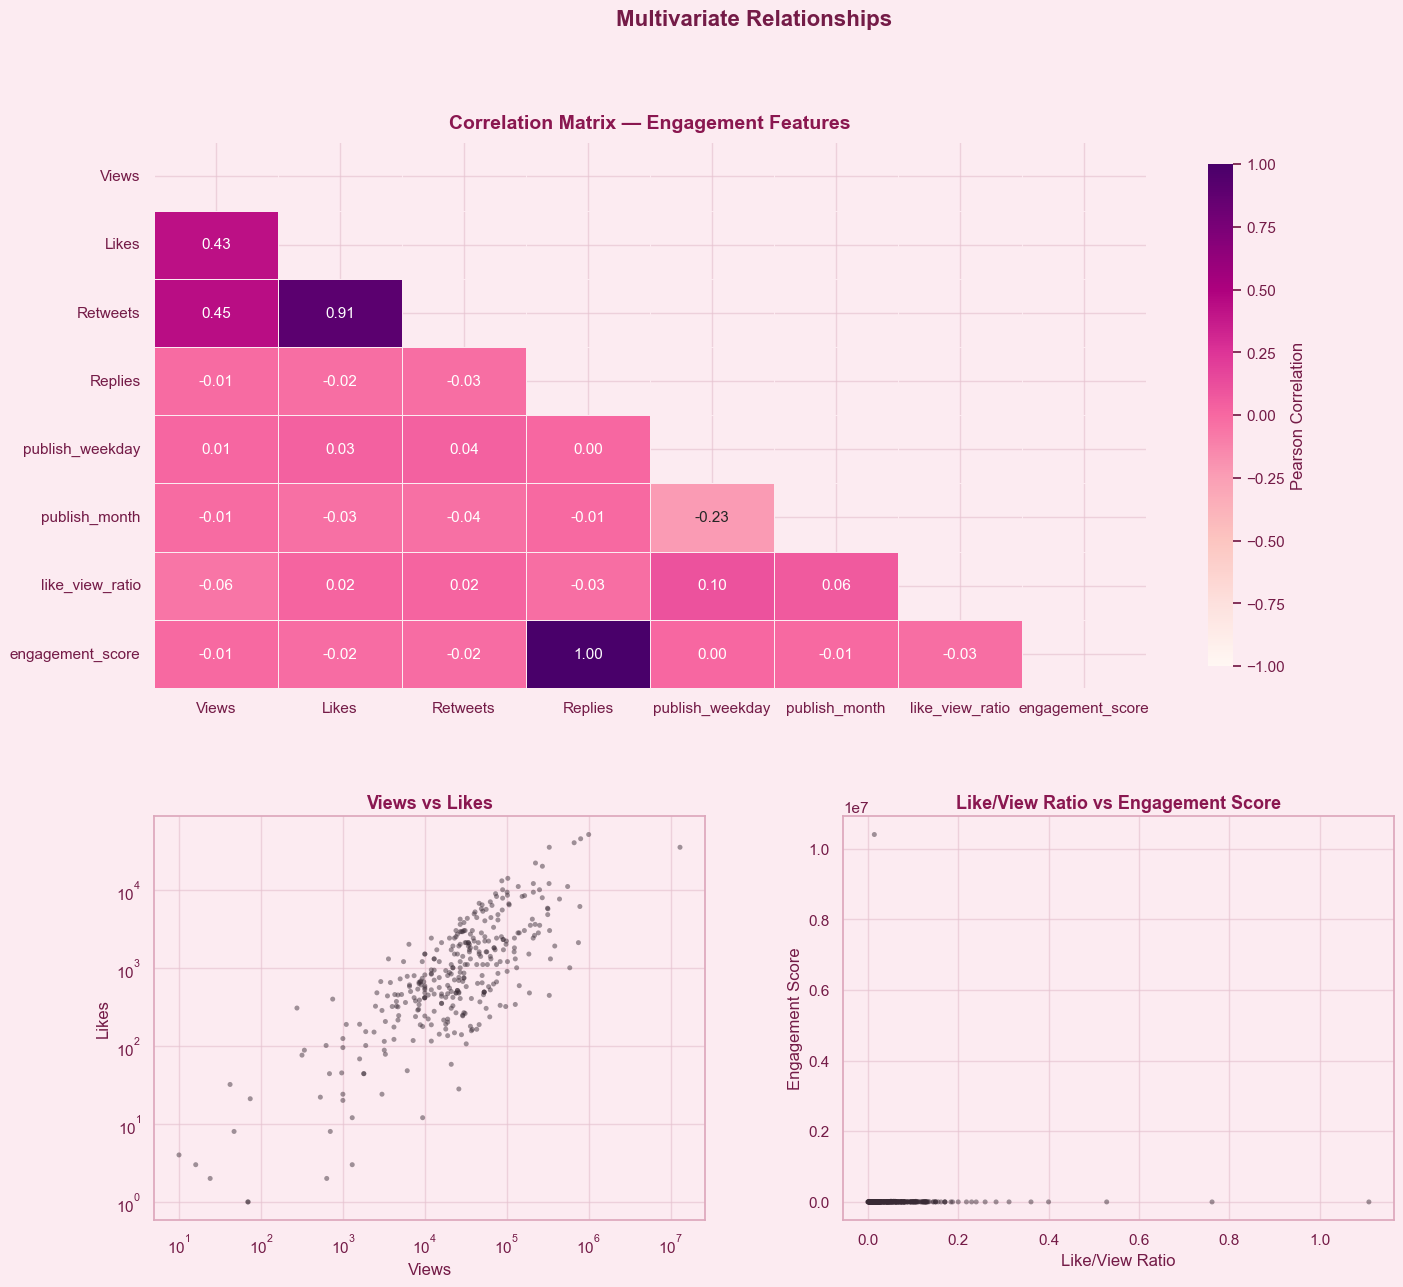

In [16]:
corr_cols = [
    "Views", "Likes", "Retweets", "Replies",
    "publish_weekday", "publish_month",
    "like_view_ratio", "engagement_score"
]

available_cols = [col for col in corr_cols if col in data.columns]
corr_data = data[available_cols].replace([np.inf, -np.inf], np.nan).dropna()
corr = corr_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "#FCEBF1",
    "axes.facecolor": "#FCEBF1",
    "axes.edgecolor": "#DDA8BC",
    "axes.labelcolor": "#741B47",
    "axes.titlecolor": "#8A1750",
    "xtick.color": "#741B47",
    "ytick.color": "#741B47",
    "text.color": "#741B47",
    "grid.color": "#E6C2D0",
    "grid.alpha": 0.65,
    "font.size": 11
})

fig = plt.figure(figsize=(16, 14), facecolor="#FCEBF1")
gs = fig.add_gridspec(2, 2, height_ratios=[1.35, 1], hspace=0.27, wspace=0.25)

ax_h = fig.add_subplot(gs[0, :])
ax_l = fig.add_subplot(gs[1, 0])
ax_r = fig.add_subplot(gs[1, 1])

sns.heatmap(
    corr,
    mask=mask,
    cmap="RdPu",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.7,
    linecolor="#FCEBF1",
    square=False,
    cbar=True,
    cbar_kws={"label": "Pearson Correlation", "shrink": 0.92, "pad": 0.05},
    ax=ax_h
)
ax_h.set_title("Correlation Matrix — Engagement Features", fontsize=14, fontweight="bold", pad=10)

sample = corr_data.sample(min(3000, len(corr_data)), random_state=42)

ax_l.scatter(sample["Views"], sample["Likes"], color="#392B35", s=13, alpha=0.48, edgecolors="none")
ax_l.set_xscale("log")
ax_l.set_yscale("log")
ax_l.set_title("Views vs Likes", fontsize=13, fontweight="bold")
ax_l.set_xlabel("Views")
ax_l.set_ylabel("Likes")

ax_r.scatter(sample["like_view_ratio"], sample["engagement_score"], color="#392B35", s=13, alpha=0.48, edgecolors="none")
ax_r.set_title("Like/View Ratio vs Engagement Score", fontsize=13, fontweight="bold")
ax_r.set_xlabel("Like/View Ratio")
ax_r.set_ylabel("Engagement Score")

for ax in [ax_h, ax_l, ax_r]:
    for spine in ax.spines.values():
        spine.set_color("#DDA8BC")

fig.suptitle("Multivariate Relationships", fontsize=16, fontweight="bold", color="#741B47", y=0.975)
plt.tight_layout()
plt.savefig("multivariate_relationships_pink.png", dpi=300, bbox_inches="tight", facecolor="#FCEBF1")
plt.show()

# Feature Selection

In [17]:
features = [
    'Likes', 'Retweets', 'Replies',
    'like_view_ratio', 'retweet_view_ratio', 'reply_view_ratio',
    'engagement_score',
    'hashtag_count', 'hashtag_length',
    'content_length', 'word_count', 'mention_count',
    'publish_hour', 'publish_weekday', 'publish_month'
]

x = data[features].fillna(0)
y = data['high_views']

# Train-Test Split


In [18]:

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Model Initialization

In [19]:
model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        eval_metric='logloss'
)

In [22]:
model.fit(x_train , y_train )
model.score(x_test , y_test)


0.9552238805970149